# 🧹 Data Cleaning — Sensor EM-300 (Temperature & Humidity)

Notebook นี้ทำ data cleaning ข้อมูลจาก raw CSV ก่อนนำไป feature engineering และ model training

**ขั้นตอน:**
1. Load & Explore
2. ตรวจสอบ near-duplicate timestamps
3. แปลง timezone (UTC → Asia/Bangkok)
4. ตรวจสอบ missing values & gaps
5. Resample เป็น 10-minute intervals
6. Interpolate ช่องว่าง
7. ตรวจสอบ outliers
8. สรุปผล & visualize ผลลัพธ์

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11

RAW_PATH = '../data/raw/sensor_data_raw.csv'

print('Libraries loaded ✅')

Libraries loaded ✅


---
## 1. Load & Explore Raw Data

In [2]:
df_raw = pd.read_csv(RAW_PATH)
df_raw['_time'] = pd.to_datetime(df_raw['_time'], format='mixed')
df_raw = df_raw.sort_values('_time').reset_index(drop=True)

print(f'Shape         : {df_raw.shape}')
print(f'Date range    : {df_raw["_time"].min()}  →  {df_raw["_time"].max()}')
print(f'Duration      : {df_raw["_time"].max() - df_raw["_time"].min()}')
df_raw.head()

Shape         : (3963, 3)
Date range    : 2026-02-05 06:51:10.157000+00:00  →  2026-03-16 01:37:54.671000+00:00
Duration      : 38 days 18:46:44.514000


,_time,hum,temp
0,2026-02-05 06:51:10.157000+00:00,36.0,28.2
1,2026-02-05 06:51:10.200000+00:00,36.0,28.2
2,2026-02-05 07:01:10.522000+00:00,35.5,28.2
3,2026-02-05 07:01:10.702000+00:00,35.5,28.2
4,2026-02-05 07:11:10.887000+00:00,36.5,28.1


In [3]:
print('=== Basic Statistics ===')
display(df_raw[['hum', 'temp']].describe().round(2))

print('\n=== Null Values ===')
print(df_raw.isnull().sum())

=== Basic Statistics ===


,hum,temp
count,3963.00,3963.00
mean,50.58,29.10
std,8.42,2.86
min,29.50,23.80
25%,44.50,26.40
50%,51.50,29.20
75%,56.00,31.30
max,70.50,34.50



=== Null Values ===
_time    0
hum      0
temp     0
dtype: int64


---
## 2. ตรวจสอบ Near-Duplicate Timestamps

Sensor บางตัวส่งค่าหลายครั้งในช่วงเวลาใกล้กัน (< 1 วินาที)  
ต้อง aggregate โดยการ round timestamp แล้ว mean ค่าที่ซ้ำกัน

In [4]:
# คำนวณ time difference ระหว่าง rows ติดกัน
df_raw['_diff_sec'] = df_raw['_time'].diff().dt.total_seconds()

near_dupes = df_raw[df_raw['_diff_sec'] < 1]
print(f'Rows ที่ห่างกันน้อยกว่า 1 วินาที: {len(near_dupes)} แถว ({len(near_dupes)/len(df_raw)*100:.1f}%)')

print('\nตัวอย่าง near-duplicate:')
display(df_raw[df_raw['_diff_sec'] < 1].head(6)[['_time', 'hum', 'temp', '_diff_sec']])

Rows ที่ห่างกันน้อยกว่า 1 วินาที: 357 แถว (9.0%)

ตัวอย่าง near-duplicate:


,_time,hum,temp,_diff_sec
1,2026-02-05 06:51:10.200000+00:00,36.0,28.2,0.043
3,2026-02-05 07:01:10.702000+00:00,35.5,28.2,0.180
6,2026-02-05 07:21:11.246000+00:00,36.0,27.9,0.011
7,2026-02-05 07:21:11.273000+00:00,36.0,27.9,0.027
9,2026-02-05 07:31:11.635000+00:00,37.5,27.8,0.036
11,2026-02-05 07:41:12.019000+00:00,38.0,27.9,0.040


In [5]:
# Round timestamp ไป 1 นาทีที่ใกล้ที่สุด แล้ว group mean
df = df_raw[['_time', 'hum', 'temp']].copy()
df['_time_rounded'] = df['_time'].dt.round('1min')

df_dedup = (
    df.groupby('_time_rounded', as_index=False)
      .agg(hum=('hum', 'mean'), temp=('temp', 'mean'))
      .rename(columns={'_time_rounded': '_time'})
)

print(f'ก่อน dedup : {len(df_raw):,} แถว')
print(f'หลัง dedup : {len(df_dedup):,} แถว  (ลดลง {len(df_raw)-len(df_dedup)} แถว)')
df_dedup.head()

ก่อน dedup : 3,963 แถว
หลัง dedup : 3,605 แถว  (ลดลง 358 แถว)


,_time,hum,temp
0,2026-02-05 06:51:00+00:00,36.0,28.2
1,2026-02-05 07:01:00+00:00,35.5,28.2
2,2026-02-05 07:11:00+00:00,36.5,28.1
3,2026-02-05 07:21:00+00:00,36.0,27.9
4,2026-02-05 07:31:00+00:00,37.5,27.8


---
## 3. แปลง Timezone → Asia/Bangkok (UTC+7)

In [6]:
# ตรวจสอบ timezone ปัจจุบัน
print('Timezone ปัจจุบัน:', df_dedup['_time'].dt.tz)

# แปลงเป็น UTC+7 แล้ว remove timezone info สำหรับ simplicity
df_dedup['_time'] = (
    df_dedup['_time']
    .dt.tz_convert('Asia/Bangkok')
    .dt.tz_localize(None)  # ลบ tzinfo ออกให้เป็น naive datetime
)

print('Timezone หลังแปลง:', df_dedup['_time'].dt.tz)
print(f'\nช่วงเวลาใหม่ (Bangkok): {df_dedup["_time"].min()}  →  {df_dedup["_time"].max()}')
df_dedup.head()

Timezone ปัจจุบัน: UTC
Timezone หลังแปลง: None

ช่วงเวลาใหม่ (Bangkok): 2026-02-05 13:51:00  →  2026-03-16 08:38:00


,_time,hum,temp
0,2026-02-05 13:51:00,36.0,28.2
1,2026-02-05 14:01:00,35.5,28.2
2,2026-02-05 14:11:00,36.5,28.1
3,2026-02-05 14:21:00,36.0,27.9
4,2026-02-05 14:31:00,37.5,27.8


---
## 4. ตรวจสอบ Missing Values & Time Gaps

In [7]:
df_dedup['_diff_min'] = df_dedup['_time'].diff().dt.total_seconds() / 60

print('=== Distribution ของ Time Interval (นาที) ===')
print(df_dedup['_diff_min'].describe().round(2))

# หา gap ที่ใหญ่ผิดปกติ (> 20 นาที ถือว่า missing)
big_gaps = df_dedup[df_dedup['_diff_min'] > 20][['_time', '_diff_min']]
big_gaps['gap_hours'] = (big_gaps['_diff_min'] / 60).round(1)

print(f'\nช่องว่างข้อมูล > 20 นาที: {len(big_gaps)} ช่วง')
display(big_gaps)

=== Distribution ของ Time Interval (นาที) ===
count    3604.00
mean       15.50
std       140.95
min         1.00
25%        10.00
50%        10.00
75%        10.00
max      8305.00
Name: _diff_min, dtype: float64

ช่องว่างข้อมูล > 20 นาที: 240 ช่วง


,_time,_diff_min,gap_hours
12,2026-02-05 16:11:00,30.0,0.5
21,2026-02-06 09:02:00,931.0,15.5
49,2026-02-06 14:22:00,50.0,0.8
59,2026-02-12 10:17:00,8305.0,138.4
63,2026-02-12 11:27:00,30.0,0.5
...,...,...,...
3572,2026-03-16 00:08:00,30.0,0.5
3573,2026-03-16 00:38:00,30.0,0.5
3578,2026-03-16 02:08:00,40.0,0.7
3579,2026-03-16 02:58:00,50.0,0.8


C:\Users\cheew\AppData\Local\Temp\ipykernel_39220\3015998432.py:15: UserWarning: Glyph 3586 (\N{THAI CHARACTER KHO KHAI}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\cheew\AppData\Local\Temp\ipykernel_39220\3015998432.py:15: UserWarning: Glyph 3629 (\N{THAI CHARACTER O ANG}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\cheew\AppData\Local\Temp\ipykernel_39220\3015998432.py:15: UserWarning: Glyph 3591 (\N{THAI CHARACTER NGO NGU}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\cheew\Desktop\Swift\Project\Predict_temp_hum\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3586 (\N{THAI CHARACTER KHO KHAI}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\cheew\Desktop\Swift\Project\Predict_temp_hum\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3629 (\N{THAI CHARACTER O ANG}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\cheew\Desktop\Swift

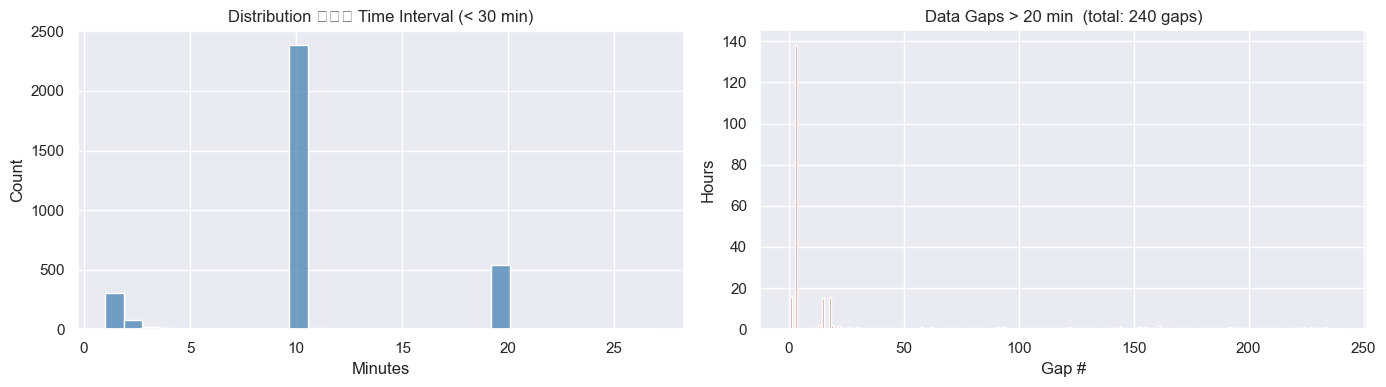

In [8]:
# แสดง distribution ของ interval (กรอง < 30 นาที เพื่อดู normal pattern)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

normal_diff = df_dedup[df_dedup['_diff_min'] < 30]['_diff_min']
sns.histplot(normal_diff, bins=30, ax=axes[0], color='steelblue')
axes[0].set_title('Distribution ของ Time Interval (< 30 min)')
axes[0].set_xlabel('Minutes')

# แสดง gap ใหญ่
axes[1].bar(range(len(big_gaps)), big_gaps['gap_hours'], color='salmon')
axes[1].set_title(f'Data Gaps > 20 min  (total: {len(big_gaps)} gaps)')
axes[1].set_xlabel('Gap #')
axes[1].set_ylabel('Hours')

plt.tight_layout()
plt.show()

---
## 5. Resample เป็น 10-Minute Regular Intervals

สร้าง time index ที่สม่ำเสมอทุก 10 นาที แล้ว merge กับข้อมูลเดิม  
ช่วงที่หายไปจะกลายเป็น NaN รอการ interpolate

In [9]:
df_idx = df_dedup.set_index('_time')[['hum', 'temp']]

# Resample ทุก 10 นาที (mean ถ้ามีหลายค่าใน window เดียวกัน)
df_resampled = df_idx.resample('10min').mean()

print(f'หลัง resample: {len(df_resampled):,} แถว  (จาก {len(df_dedup):,} แถว)')
print(f'Missing หลัง resample: temp={df_resampled["temp"].isna().sum()}, hum={df_resampled["hum"].isna().sum()}')
df_resampled.head(10)

หลัง resample: 5,585 แถว  (จาก 3,605 แถว)
Missing หลัง resample: temp=2338, hum=2338


,hum,temp
_time,,
2026-02-05 13:50:00,36.0,28.2
2026-02-05 14:00:00,35.5,28.2
2026-02-05 14:10:00,36.5,28.1
2026-02-05 14:20:00,36.0,27.9
2026-02-05 14:30:00,37.5,27.8
2026-02-05 14:40:00,38.0,27.9
2026-02-05 14:50:00,41.0,27.9
2026-02-05 15:00:00,39.0,27.9
2026-02-05 15:10:00,39.0,27.9


---
## 6. Interpolate ช่องว่าง

ใช้ `method='time'` เพื่อ interpolate ตาม timestamp จริง  
Gap ที่ใหญ่มาก (> 6 ชั่วโมง) ให้ limit ไม่ interpolate ข้ามไกลเกิน

In [10]:
# limit = 36 → ไม่ interpolate ข้าม gap ที่ใหญ่กว่า 6 ชม (36 * 10min)
df_interp = df_resampled.interpolate(method='time', limit=36)

remaining_na = df_interp.isna().sum()
print(f'Missing หลัง interpolate: temp={remaining_na["temp"]}, hum={remaining_na["hum"]}')

if remaining_na.sum() > 0:
    print('\nช่วงที่ยังเป็น NaN (gap ใหญ่เกิน 6 ชม):')
    display(df_interp[df_interp.isna().any(axis=1)].head(10))

Missing หลัง interpolate: temp=961, hum=961

ช่วงที่ยังเป็น NaN (gap ใหญ่เกิน 6 ชม):


,hum,temp
_time,,
2026-02-05 23:40:00,NaN,NaN
2026-02-05 23:50:00,NaN,NaN
2026-02-06 00:00:00,NaN,NaN
2026-02-06 00:10:00,NaN,NaN
2026-02-06 00:20:00,NaN,NaN
2026-02-06 00:30:00,NaN,NaN
2026-02-06 00:40:00,NaN,NaN
2026-02-06 00:50:00,NaN,NaN
2026-02-06 01:00:00,NaN,NaN


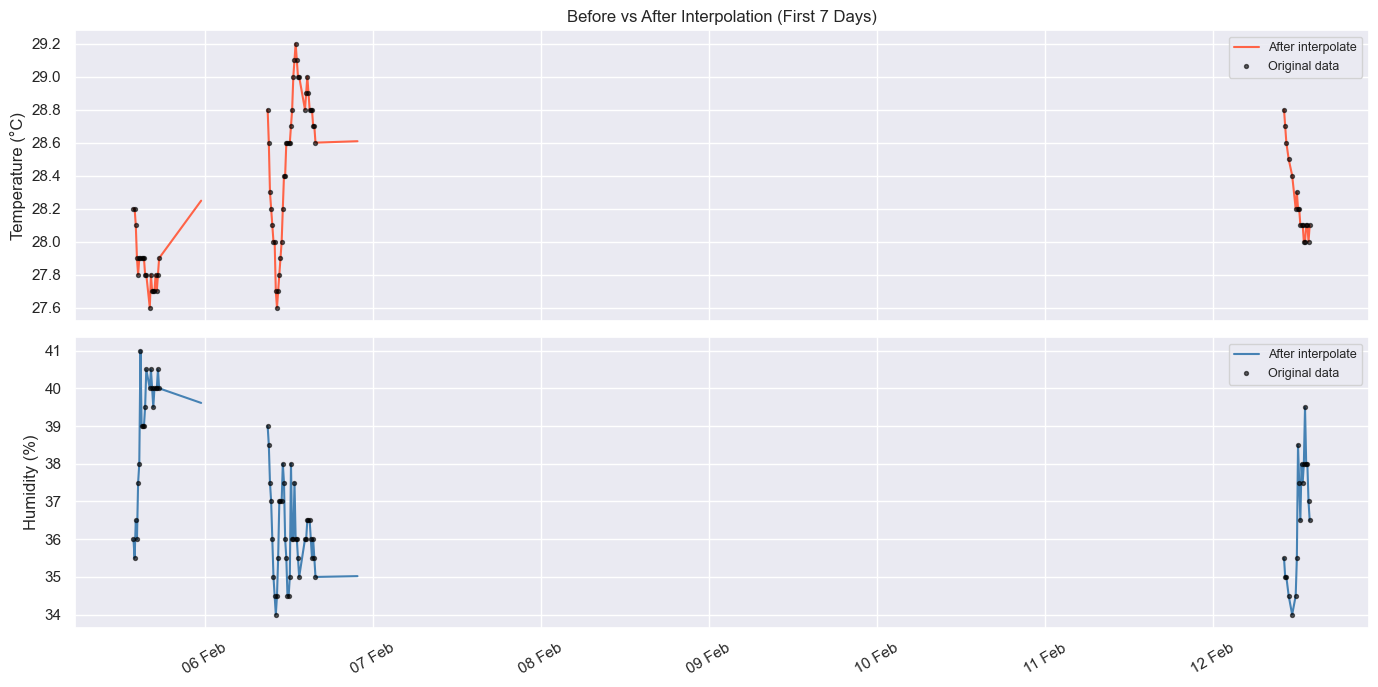

In [11]:
# เปรียบเทียบก่อน/หลัง interpolation ในช่วงตัวอย่าง
sample_start = df_resampled.index.min()
sample_end   = sample_start + pd.Timedelta(days=7)

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

for ax, col, color, label in zip(
    axes,
    ['temp', 'hum'],
    ['tomato', 'steelblue'],
    ['Temperature (°C)', 'Humidity (%)']
):
    before = df_resampled.loc[sample_start:sample_end, col]
    after  = df_interp.loc[sample_start:sample_end, col]

    ax.plot(after.index,  after.values,  color=color, linewidth=1.5, label='After interpolate', zorder=2)
    ax.scatter(before.dropna().index, before.dropna().values,
               color='black', s=8, zorder=3, label='Original data', alpha=0.6)
    ax.set_ylabel(label)
    ax.legend(loc='upper right', fontsize=9)

axes[0].set_title('Before vs After Interpolation (First 7 Days)')
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

---
## 7. ตรวจสอบ Outliers

ใช้ IQR method: ค่านอก `[Q1 - 1.5×IQR, Q3 + 1.5×IQR]` ถือว่า outlier  
สำหรับ sensor data อาจใช้ rolling z-score เพิ่มเติม

temp  | range [20.6, 37.2] | outliers: 0
hum   | range [29.0, 73.0] | outliers: 0


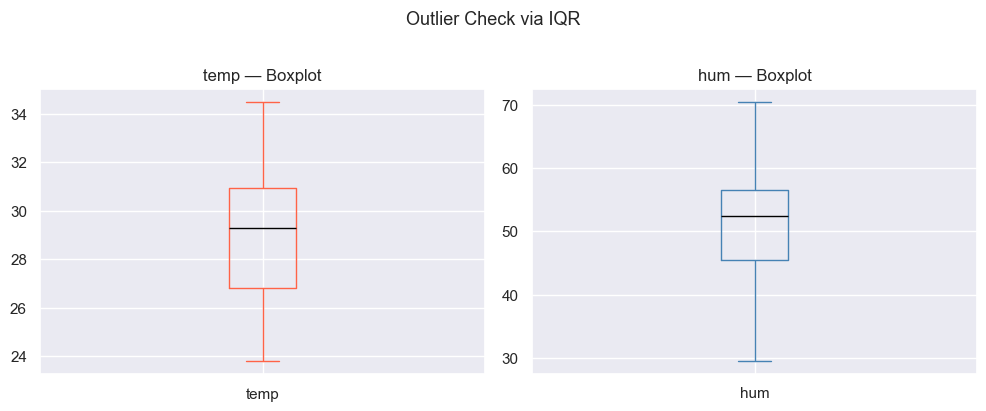

In [12]:
df_clean = df_interp.copy()

for col in ['temp', 'hum']:
    Q1  = df_clean[col].quantile(0.25)
    Q3  = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_out = ((df_clean[col] < lo) | (df_clean[col] > hi)).sum()
    print(f'{col:5s} | range [{lo:.1f}, {hi:.1f}] | outliers: {n_out}')

# Boxplot
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, col, color in zip(axes, ['temp', 'hum'], ['tomato', 'steelblue']):
    df_clean[col].plot.box(ax=ax, color=dict(boxes=color, medians='black', whiskers=color, caps=color))
    ax.set_title(f'{col} — Boxplot')
plt.suptitle('Outlier Check via IQR', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

temp  | rolling z-score spikes (|z|>3): 3
hum   | rolling z-score spikes (|z|>3): 7


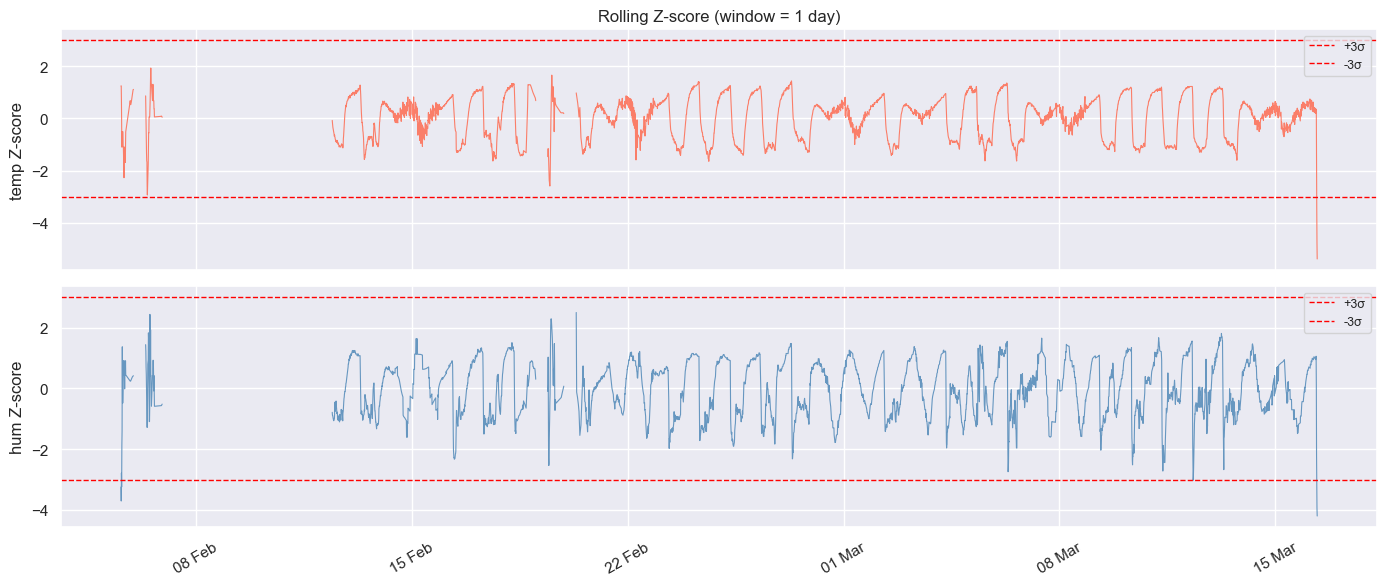

In [13]:
# Rolling Z-score (window = 144 = 1 วัน)
WINDOW = 144

for col in ['temp', 'hum']:
    roll_mean = df_clean[col].rolling(WINDOW, center=True, min_periods=1).mean()
    roll_std  = df_clean[col].rolling(WINDOW, center=True, min_periods=1).std()
    z_score   = (df_clean[col] - roll_mean) / roll_std.replace(0, np.nan)
    df_clean[f'{col}_zscore'] = z_score
    spike_mask = z_score.abs() > 3
    print(f'{col:5s} | rolling z-score spikes (|z|>3): {spike_mask.sum()}')

# Visualize z-score
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
for ax, col, color in zip(axes, ['temp', 'hum'], ['tomato', 'steelblue']):
    ax.plot(df_clean.index, df_clean[f'{col}_zscore'], color=color, linewidth=0.8, alpha=0.8)
    ax.axhline( 3, color='red',  linestyle='--', linewidth=1, label='+3σ')
    ax.axhline(-3, color='red',  linestyle='--', linewidth=1, label='-3σ')
    ax.set_ylabel(f'{col} Z-score')
    ax.legend(loc='upper right', fontsize=9)

axes[0].set_title('Rolling Z-score (window = 1 day)')
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# Drop z-score columns
df_clean.drop(columns=['temp_zscore', 'hum_zscore'], inplace=True)

---
## 8. สรุปผลและ Visualize ข้อมูลสุดท้าย

In [14]:
print('=' * 50)
print('         CLEANING SUMMARY')
print('=' * 50)
print(f'Raw rows               : {len(df_raw):>8,}')
print(f'After dedup            : {len(df_dedup):>8,}')
print(f'After resample (10min) : {len(df_resampled):>8,}')
print(f'After interpolate      : {len(df_interp):>8,}')
print(f'Remaining NaN          : {df_interp.isna().sum().sum():>8}')
print('=' * 50)
print(f'Date range  : {df_clean.index.min()}  →  {df_clean.index.max()}')
print()
display(df_clean.describe().round(2))

         CLEANING SUMMARY
Raw rows               :    3,963
After dedup            :    3,605
After resample (10min) :    5,585
After interpolate      :    5,585
Remaining NaN          :     1922
Date range  : 2026-02-05 13:50:00  →  2026-03-16 08:30:00



,hum,temp
count,4624.00,4624.00
mean,51.51,29.07
std,8.55,2.58
min,29.50,23.80
25%,45.50,26.80
50%,52.50,29.30
75%,56.50,30.95
max,70.50,34.50


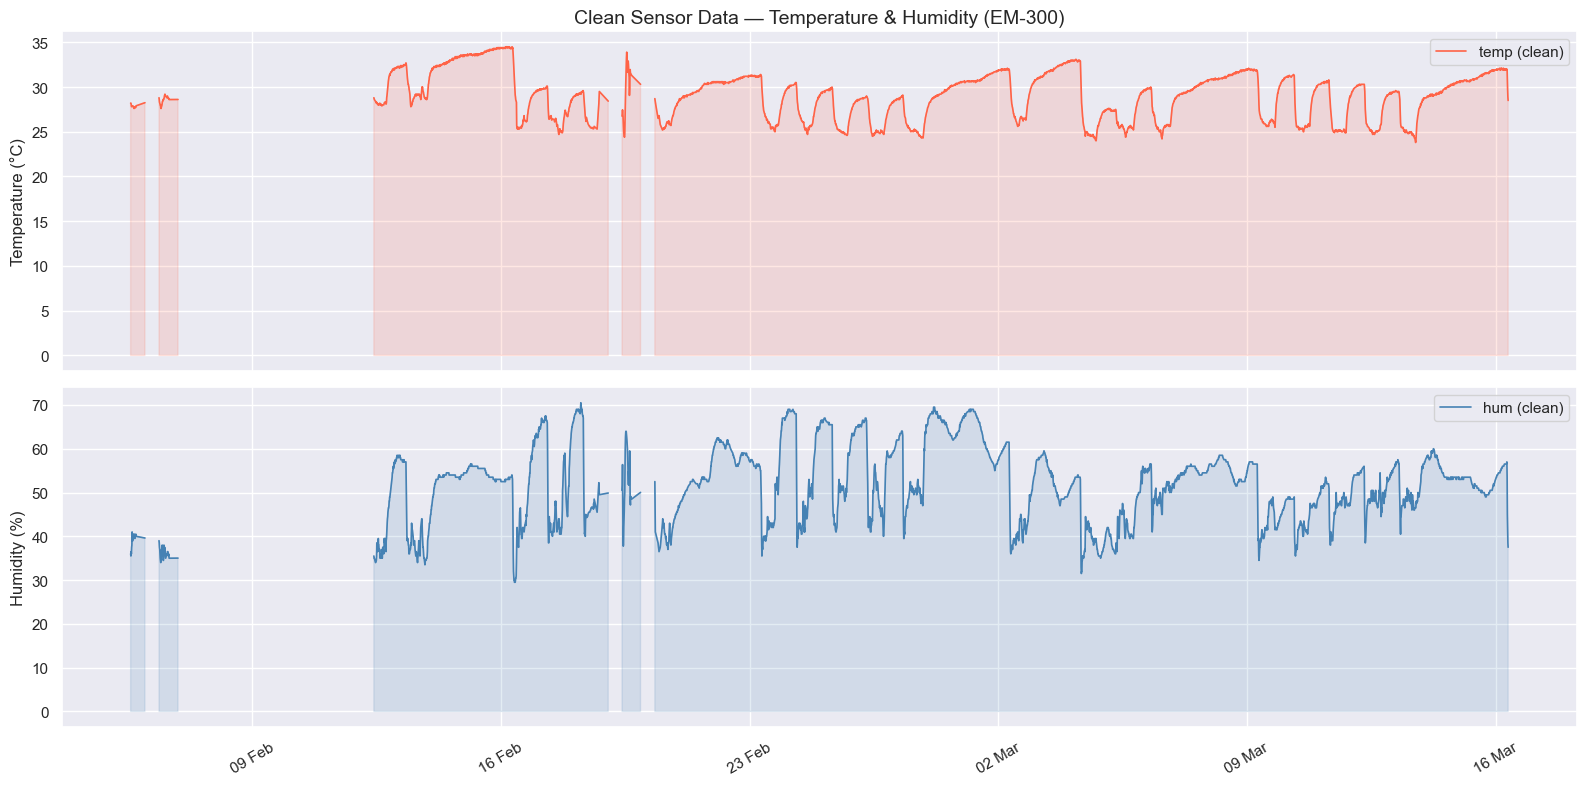

In [15]:
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

# Temperature
ax1 = axes[0]
ax1.plot(df_clean.index, df_clean['temp'], color='tomato', linewidth=1.2, label='temp (clean)')
ax1.fill_between(df_clean.index, df_clean['temp'], alpha=0.15, color='tomato')
ax1.set_ylabel('Temperature (°C)', fontsize=12)
ax1.set_title('Clean Sensor Data — Temperature & Humidity (EM-300)', fontsize=14)
ax1.legend(loc='upper right')

# Humidity
ax2 = axes[1]
ax2.plot(df_clean.index, df_clean['hum'], color='steelblue', linewidth=1.2, label='hum (clean)')
ax2.fill_between(df_clean.index, df_clean['hum'], alpha=0.15, color='steelblue')
ax2.set_ylabel('Humidity (%)', fontsize=12)
ax2.legend(loc='upper right')

ax2.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax2.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

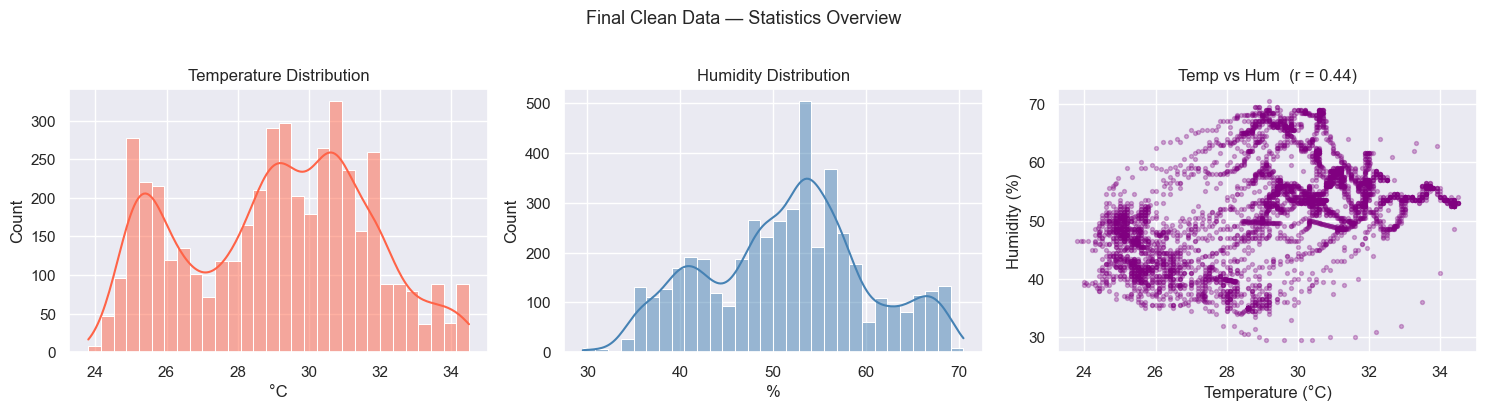

In [16]:
# Distribution + Correlation
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(df_clean['temp'], ax=axes[0], kde=True, color='tomato', bins=30)
axes[0].set_title('Temperature Distribution')
axes[0].set_xlabel('°C')

sns.histplot(df_clean['hum'], ax=axes[1], kde=True, color='steelblue', bins=30)
axes[1].set_title('Humidity Distribution')
axes[1].set_xlabel('%')

axes[2].scatter(df_clean['temp'], df_clean['hum'],
                alpha=0.3, s=8, color='purple')
corr = df_clean[['temp','hum']].corr().loc['temp','hum']
axes[2].set_title(f'Temp vs Hum  (r = {corr:.2f})')
axes[2].set_xlabel('Temperature (°C)')
axes[2].set_ylabel('Humidity (%)')

plt.suptitle('Final Clean Data — Statistics Overview', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## ✅ หมายเหตุ

Notebook นี้เป็นเพียงการ**แสดงขั้นตอน** data cleaning ยังไม่ได้ save ไฟล์ clean data ออกมา  
เมื่อพร้อม ให้เพิ่ม cell ด้านล่างนี้:

```python
# CLEAN_PATH = '../data/processed/sensor_data_clean.csv'
# df_clean.to_csv(CLEAN_PATH)
# print(f'Saved → {CLEAN_PATH}')
```